In [7]:
'''Для запуска кода требуются библиотеки: pandas, numpy, numba, sympy, scipy
Установить библиотеку можно следующим образом:
1. windows - в командной строке ввести: py -mpip install numpy
2. linux - в командной строке ввести: python3 -mpip install numpy
'''

from pyscarcopulas.copula_src.N22.N22Copula import N22Copula
from pyscarcopulas.copula_src.Gumbel.GumbelCopula  import GumbelCopula
from pyscarcopulas.copula_src.Frank.FrankCopula  import FrankCopula
from pyscarcopulas.copula_src.Joe.JoeCopula  import JoeCopula

from pyscarcopulas.aux_functions.funcs import rank
from pyscarcopulas.aux_functions.funcs import transform_pseudo_obs

import pandas as pd
import numpy as np
import sympy as sp

In [4]:
'''Читаем данные и и переводим ретурны в псевдонаблюдения'''
returns_data = pd.read_csv(r"data/test_returns_data_for_eis.csv", index_col=0) #данные мосбиржи
#returns_data = pd.read_csv(r"data/dj.csv", index_col=0) - доступен другой датасет (из статьи)
pseudo_obs_data = transform_pseudo_obs(returns_data.values)

In [35]:
'''Чтобы воспользоваться функционалом нужно создать элемент класса, например, GumbelCopula(dim), где dim - размерность'''
gum_cop = GumbelCopula(2)
'''Каждая копула обладает общим набором методов:
1. sp_cdf() - возвращает sympy выражение cdf копулы (u0, u1, ..., ud, r), где r - параметр копулы
2. sp_pdf() - возвращает sympy выражение pdf копулы
3. pdf(array) - вычислить pdf в точке [u0, u1, ..., ud]'''

'''cdf'''
gum_cop.sp_cdf()


exp(-((-log(u0))**r + (-log(u1))**r)**(1/r))

In [37]:
'''pdf'''
gum_cop.sp_pdf()

(-log(u0))**r*(-log(u1))**r*((-log(u0))**r + (-log(u1))**r)**(1/r)*(r + ((-log(u0))**r + (-log(u1))**r)**(1/r) - 1)*exp(-((-log(u0))**r + (-log(u1))**r)**(1/r))/(u0*u1*((-log(u0))**r + (-log(u1))**r)**2*log(u0)*log(u1))

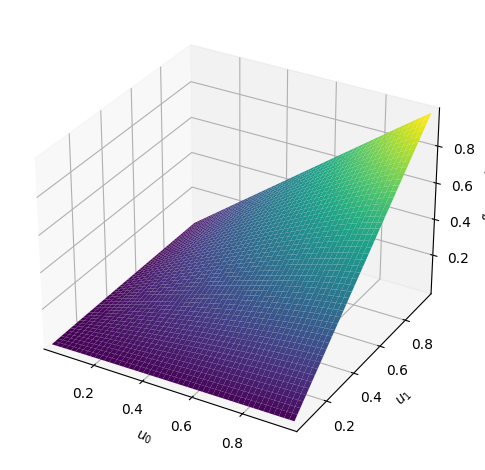

In [38]:
'''с sympy выражениями можно работать методами sympy. Например, можно построить график cdf'''
u0, u1, r = sp.symbols('u0 u1 r')
sp.plotting.plot3d( gum_cop.sp_cdf().subs([(r, 1.2)]) , (u0, 0.01, 0.99), (u1, 0.01, 0.99))

In [42]:
'''Аппроксимировать копулу можно вызвав метод fit. 
Доступные методы аппроксимации:
1. MLE - метод макс. правдоподобия
2. SCAR-M - efficient importance sampling (по-умолчанию)
3. SCAR-P - Natural sampler 

Ниже пример аппроксимации копулы Joe. В процессе работы минимайзера выводится точка и значение функции в ней (оставил этот вывод, т.к. пока я еще отлаживаю процесс вычислений)
Результат расчётов - fun - значение log likelihood (для SCAR-P и M - среднее значение по числу траекторий n_tr); x - набор параметров регрессии omega.

Первый запуск может длиться дольше, т.к. в расчётах присутствует оптимизация библиотеки numba - для ряда функций сперва происходит компиляция в низкоуровневый машинный код, 
запуск которого происходит значительно быстрее, но компиляция занимает какое-то время.
'''
joe_cop = JoeCopula(4)
joe_cop.fit(pseudo_obs_data[0:500], n_tr = 200, m_iters = 5, method = 'SCAR-M')

[0.05 0.95 0.05] -34.88828486115793
[0.05000001 0.95       0.05      ] -34.88826646364319
[0.05       0.95000001 0.05      ] -34.88826712706834
[0.05       0.95       0.05000001] -34.88828560813001
[-0.66966145  0.25628996  0.07921955] -38.72017712909682
[-0.66966144  0.25628996  0.07921955] -38.72017844912343
[-0.66966145  0.25628997  0.07921955] -38.72017594314556
[-0.66966145  0.25628996  0.07921956] -38.72017721460645
[-0.62212691  0.20732821  0.08265272] -46.13536243375926
[-0.6221269   0.20732821  0.08265272] -46.13536284421339
[-0.62212691  0.20732822  0.08265272] -46.13536211165753
[-0.62212691  0.20732821  0.08265273] -46.135362440369484
[-0.60118601  0.18851166  0.08268025] -47.09730804074951
[-0.601186    0.18851166  0.08268025] -47.0973081834021
[-0.60118601  0.18851167  0.08268025] -47.097307935721055
[-0.60118601  0.18851166  0.08268026] -47.09730805498184
[-0.5902153   0.1791259   0.08417992] -47.247010154927594
[-0.59021529  0.1791259   0.08417992] -47.24701018016965
[-

      fun: 47.26043890264624
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
      jac: array([-0.01174953, -0.01457607,  0.03901803])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
   method: 'SCAR-M'
     nfev: 36
      nit: 8
     njev: 9
   status: 0
  success: True
        x: array([-0.58711923,  0.17694099,  0.09285159])

In [44]:
fra_cop = FrankCopula(4)
fra_cop.fit(pseudo_obs_data[0:500], n_tr = 200, m_iters = 5, method = 'SCAR-M')

[0.05 0.95 0.05] -50.2263446627423
[0.05000001 0.95       0.05      ] -50.226348096849776
[0.05       0.95000001 0.05      ] -50.22634833070237
[0.05       0.95       0.05000001] -50.226344902138344
[0.7326788  1.67916721 0.09759042] params is out of bounds 10000
[0.73267881 1.67916721 0.09759042] params is out of bounds 10000
[0.7326788  1.67916722 0.09759042] params is out of bounds 10000
[0.7326788  1.67916721 0.09759043] params is out of bounds 10000
[0.05555587 0.95593421 0.05038731] -53.517834563601234
[0.05555588 0.95593421 0.05038731] -53.517836207513476
[0.05555587 0.95593422 0.05038731] -53.517836826233186
[0.05555587 0.95593421 0.05038732] -53.517834761234425
[0.06071125 0.96544464 0.05140274] -53.14730343732209
[0.06071126 0.96544464 0.05140274] -53.14730070985324
[0.06071125 0.96544465 0.05140274] -53.14729906857375
[0.06071125 0.96544464 0.05140275] -53.14730379866433
[0.05801382 0.96046854 0.05087144] -54.35979968021364
[0.05801383 0.96046854 0.05087144] -54.359799682191

c:\Users\3dgnom\Downloads\vs_Code_Sirius_Project\moex data\scar\pyscarcopulas\copula_src\ArchimedianCopula.py:239: RuntimeWarning: invalid value encountered in log
  copula_log_data = np.sum(np.log(self.np_pdf()(data[t], self.transform(lambda_data[t]) )) )


[0.00772349 0.99557363 0.15683921] m sampler nan 10000
[0.0077235  0.99557363 0.15683921] m sampler nan 10000
[0.00772349 0.99557364 0.15683921] m sampler nan 10000
[0.00772349 0.99557363 0.15683922] m sampler nan 10000
[0.03801527 0.97869187 0.09688461] -55.65343429239801
[0.03801528 0.97869187 0.09688461] -55.65343181458
[0.03801527 0.97869188 0.09688461] -55.65343077276425
[0.03801527 0.97869187 0.09688462] -55.653434566001266
[0.03801366 0.97869276 0.0968878 ] -55.65360443714992
[0.03801367 0.97869276 0.0968878 ] -55.65360195935926
[0.03801366 0.97869277 0.0968878 ] -55.653600917871955
[0.03801366 0.97869276 0.09688781] -55.65360471061377
[0.02286857 0.9871332  0.1268635 ] m sampler nan 10000
[0.02286858 0.9871332  0.1268635 ] m sampler nan 10000
[0.02286857 0.98713321 0.1268635 ] m sampler nan 10000
[0.02286857 0.9871332  0.12686351] m sampler nan 10000
[0.03801326 0.97869299 0.09688859] -55.65364696612027
[0.03801327 0.97869299 0.09688859] -55.65364448853253
[0.03801326 0.978693 

      fun: 56.199873110141404
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
      jac: array([178.22790067, 238.7272604 , -16.37958392])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
   method: 'SCAR-M'
     nfev: 172
      nit: 10
     njev: 43
   status: 0
  success: True
        x: array([0.03182677, 0.98221444, 0.10913225])

In [46]:
'''Запустить процесс на меньшем числе переменных можно следующим образом'''
gum_cop = GumbelCopula(2)
gum_cop.fit(pseudo_obs_data[:,1:3][0:500], n_tr = 10000, method = 'SCAR-P')


[0.05 0.95 0.05] -52.24306139109111
[0.05000001 0.95       0.05      ] -52.243058985695015
[0.05       0.95000001 0.05      ] -52.243059381866026
[0.05       0.95       0.05000001] -52.24306183693924
[-0.7098292   0.31531539  0.19083686] -49.888090679091505
[-0.70982919  0.31531539  0.19083686] -49.88809122724408
[-0.7098292   0.3153154   0.19083686] -49.88809012716125
[-0.7098292   0.31531539  0.19083687] -49.888090728352196
[-0.20189291  0.73959409  0.09668919] -48.13114804675841
[-0.2018929   0.73959409  0.09668919] -48.13114646984941
[-0.20189291  0.7395941   0.09668919] -48.131149321676354
[-0.20189291  0.73959409  0.0966892 ] -48.131148223561944
[-0.02315953  0.88888991  0.06356036] -10.427511161645905
[-0.02315952  0.88888991  0.06356036] -10.427505676633576
[-0.02315953  0.88888992  0.06356036] -10.427512757813105
[-0.02315953  0.88888991  0.06356037] -10.427512331295894
[0.04447545 0.94538535 0.05102399] -51.23443536334359
[0.04447546 0.94538535 0.05102399] -51.23443978313726


      fun: 53.85660807340856
 hess_inv: <3x3 LbfgsInvHessProduct with dtype=float64>
      jac: array([-1.17589067, -1.30642945, -0.1685514 ])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
   method: 'SCAR-P'
     nfev: 100
      nit: 14
     njev: 25
   status: 0
  success: True
        x: array([0.04451622, 0.9485364 , 0.1049588 ])

In [55]:
'''MLE'''
gum_cop.fit(pseudo_obs_data[:,1:3][0:500], method = 'MLE')


      fun: 50.57519897126901
 hess_inv: <1x1 LbfgsInvHessProduct with dtype=float64>
      jac: array([-0.0004043])
  message: 'CONVERGENCE: REL_REDUCTION_OF_F_<=_FACTR*EPSMCH'
   method: 'MLE'
     nfev: 16
      nit: 6
     njev: 8
   status: 0
  success: True
        x: array([1.45721702])